# Taller 07: Clasificadores KNN y RNN
**Inteligencia Artificial — ELP 8012 — Universidad del Norte**
**Profesor:** Eduardo Zurek, Ph.D.

**Integrantes del grupo:**
- Gabriel Caicedo
- Alan Garcia
- Alejandra Restrepo

## Objetivo
Diseñar e implementar, usando el dataset `digits` de scikit-learn, dos clasificadores de dígitos escritos a mano:

1. **KNN (K-Nearest Neighbors)**
2. **RNN (Radius Neighbors Classifier)**

### Metodología
- División del dataset: **80% entrenamiento / 20% prueba** (estratificada, para conservar la proporción de clases).
- Validación cruzada con **K-fold = 4** sobre el conjunto de entrenamiento, para seleccionar el mejor hiperparámetro de cada modelo.
- Para KNN se explora un rango de valores de **K** (número de vecinos).
- Para RNN se explora un rango de valores de **R** (radio de vecindad).
- En ambos casos se grafican las métricas de desempeño (accuracy, precision, recall y F1, promediadas macro) en función del hiperparámetro, se selecciona el mejor valor y se evalúa el modelo final sobre el conjunto de prueba.


## 1. Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams['figure.figsize'] = (8, 5)

## 2. Carga y exploración del dataset `digits`

El dataset `digits` de scikit-learn contiene **1797 imágenes** de dígitos escritos a mano (0 al 9), cada una representada como una matriz de **8x8 píxeles** en escala de grises (valores de intensidad entre 0 y 16). Para los clasificadores, cada imagen se representa como un vector de **64 características**.


In [2]:
digits = load_digits()
X = digits.data      # (n_samples, 64)
y = digits.target    # (n_samples,)

print(f"Forma de X (features): {X.shape}")
print(f"Forma de y (etiquetas): {y.shape}")
print(f"Clases: {np.unique(y)}")
print(f"Rango de valores de intensidad: [{X.min()}, {X.max()}]")

Forma de X (features): (1797, 64)
Forma de y (etiquetas): (1797,)
Clases: [0 1 2 3 4 5 6 7 8 9]
Rango de valores de intensidad: [0.0, 16.0]


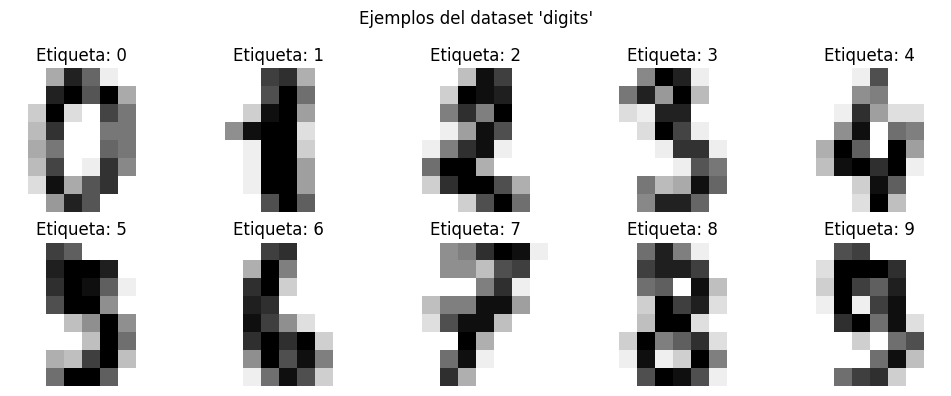

In [3]:
# Visualización de algunos dígitos de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f"Etiqueta: {digits.target[i]}")
    ax.axis('off')
plt.suptitle("Ejemplos del dataset 'digits'")
plt.tight_layout()
plt.show()

## 3. División del dataset: 80% entrenamiento / 20% prueba

Se realiza una división estratificada para conservar la proporción de cada clase (dígito) tanto en el conjunto de entrenamiento como en el de prueba.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Tamaño conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño conjunto de prueba: {X_test.shape[0]} muestras")

Tamaño conjunto de entrenamiento: 1437 muestras
Tamaño conjunto de prueba: 360 muestras


## 4. Configuración de la validación cruzada (K-fold = 4)

Para seleccionar los hiperparámetros de cada modelo se usa `StratifiedKFold` con **4 particiones (folds)** sobre el conjunto de entrenamiento. En cada combinación de hiperparámetro se calculan 4 métricas de desempeño promediadas sobre los 4 folds: **accuracy**, **precision (macro)**, **recall (macro)** y **F1-score (macro)**.


In [5]:
kfold = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1': 'f1_macro'
}

def evaluar_modelo_cv(modelo, X, y, cv, scoring):
    # Ejecuta validación cruzada y devuelve el promedio de cada métrica.
    resultados = cross_validate(modelo, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        'accuracy': resultados['test_accuracy'].mean(),
        'precision': resultados['test_precision'].mean(),
        'recall': resultados['test_recall'].mean(),
        'f1': resultados['test_f1'].mean()
    }

## 5. Clasificador KNN: exploración del rango de K

Se evalúa el clasificador **KNeighborsClassifier** para un rango de valores de K entre **1 y 20**, usando validación cruzada de 4 folds sobre el conjunto de entrenamiento.


In [6]:
rango_K = range(1, 21)  # K de 1 a 20

metricas_knn = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

for K in rango_K:
    modelo_knn = KNeighborsClassifier(n_neighbors=K)
    resultado = evaluar_modelo_cv(modelo_knn, X_train, y_train, kfold, scoring)
    for m in metricas_knn:
        metricas_knn[m].append(resultado[m])

print("Validación cruzada (K-fold=4) completada para K = 1..20")


Validación cruzada (K-fold=4) completada para K = 1..20


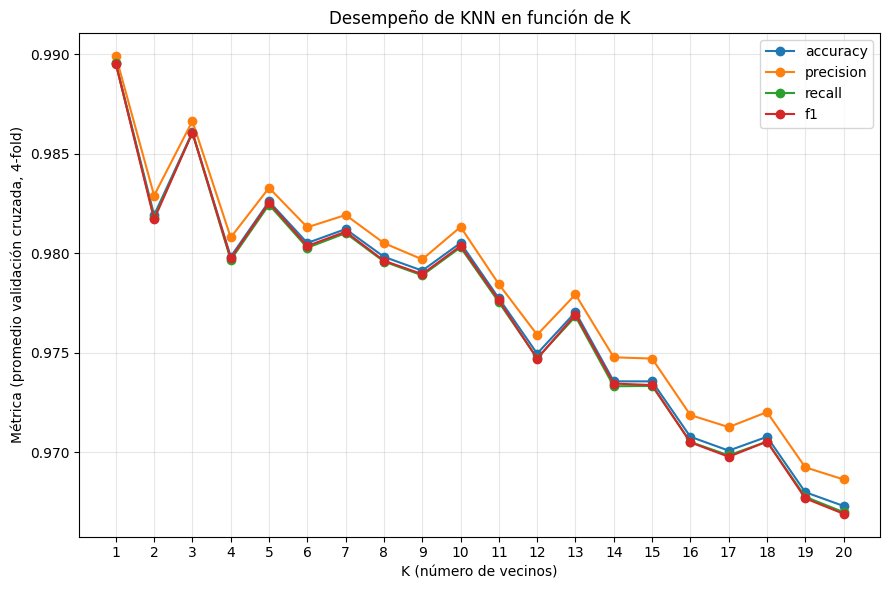

In [7]:
# Figura: métricas de desempeño vs K
plt.figure(figsize=(9, 6))
for m, valores in metricas_knn.items():
    plt.plot(list(rango_K), valores, marker='o', label=m)
plt.xlabel('K (número de vecinos)')
plt.ylabel('Métrica (promedio validación cruzada, 4-fold)')
plt.title('Desempeño de KNN en función de K')
plt.xticks(list(rango_K))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('knn_metricas_vs_K.png', dpi=120)
plt.show()


### Selección del mejor valor de K

El mejor valor de K se selecciona como aquel que maximiza el **F1-score macro** promedio en la validación cruzada (métrica robusta frente a un eventual desbalance entre clases).


In [8]:
mejor_idx_K = int(np.argmax(metricas_knn['f1']))
mejor_K = list(rango_K)[mejor_idx_K]

print(f"Mejor valor de K: {mejor_K}")
print(f"  Accuracy  (CV): {metricas_knn['accuracy'][mejor_idx_K]:.4f}")
print(f"  Precision (CV): {metricas_knn['precision'][mejor_idx_K]:.4f}")
print(f"  Recall    (CV): {metricas_knn['recall'][mejor_idx_K]:.4f}")
print(f"  F1-score  (CV): {metricas_knn['f1'][mejor_idx_K]:.4f}")


Mejor valor de K: 1
  Accuracy  (CV): 0.9896
  Precision (CV): 0.9899
  Recall    (CV): 0.9895
  F1-score  (CV): 0.9895


### Evaluación del modelo KNN final sobre el conjunto de prueba

In [9]:
modelo_knn_final = KNeighborsClassifier(n_neighbors=mejor_K)
modelo_knn_final.fit(X_train, y_train)
y_pred_knn = modelo_knn_final.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn, average='macro')
rec_knn = recall_score(y_test, y_pred_knn, average='macro')
f1_knn = f1_score(y_test, y_pred_knn, average='macro')

print(f"Resultados KNN (K={mejor_K}) sobre el conjunto de PRUEBA:")
print(f"  Accuracy : {acc_knn:.4f}")
print(f"  Precision: {prec_knn:.4f}")
print(f"  Recall   : {rec_knn:.4f}")
print(f"  F1-score : {f1_knn:.4f}")
print()
print(classification_report(y_test, y_pred_knn))


Resultados KNN (K=1) sobre el conjunto de PRUEBA:
  Accuracy : 0.9861
  Precision: 0.9866
  Recall   : 0.9859
  F1-score : 0.9859

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.91      0.94        35
           9       1.00      0.94      0.97        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



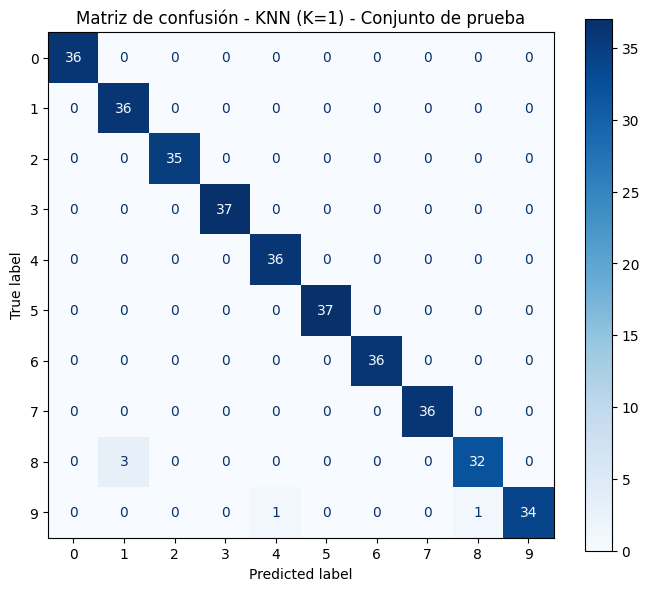

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, ax=ax, cmap='Blues')
ax.set_title(f'Matriz de confusión - KNN (K={mejor_K}) - Conjunto de prueba')
plt.tight_layout()
plt.savefig('knn_matriz_confusion.png', dpi=120)
plt.show()


## 6. Clasificador RNN (Radius Neighbors): exploración del rango de R

`RadiusNeighborsClassifier` clasifica una muestra según la clase mayoritaria entre todos los vecinos que se encuentren dentro de un **radio R** de distancia (en vez de un número fijo de vecinos como en KNN).

### Selección del rango de R

Como las 64 características tienen valores entre 0 y 16, la escala de las distancias euclidianas entre dígitos es distinta a la de otros datasets. Para elegir un rango razonable de R se inspeccionó la distribución de distancias entre muestras del conjunto de entrenamiento (distancia al vecino más cercano ≈ 7 a 34, y percentiles de distancia entre pares de muestras entre ~23 y ~64). Con base en esa exploración, se define el rango:

**R = 15, 18, 21, ..., 48** (paso de 3), que cubre desde radios muy pequeños (pocos o ningún vecino) hasta radios grandes (demasiados vecinos, se mezclan clases).

Cuando para una muestra no existe ningún vecino dentro del radio R, se usa `outlier_label='most_frequent'` para asignarle la clase más frecuente del conjunto de entrenamiento, evitando errores de predicción.


In [11]:
rango_R = list(range(15, 49, 3))  # R de 15 a 48, paso 3

metricas_rnn = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

for R in rango_R:
    modelo_rnn = RadiusNeighborsClassifier(radius=R, outlier_label='most_frequent')
    resultado = evaluar_modelo_cv(modelo_rnn, X_train, y_train, kfold, scoring)
    for m in metricas_rnn:
        metricas_rnn[m].append(resultado[m])

print("Validación cruzada (K-fold=4) completada para R =", rango_R)


Validación cruzada (K-fold=4) completada para R = [15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48]


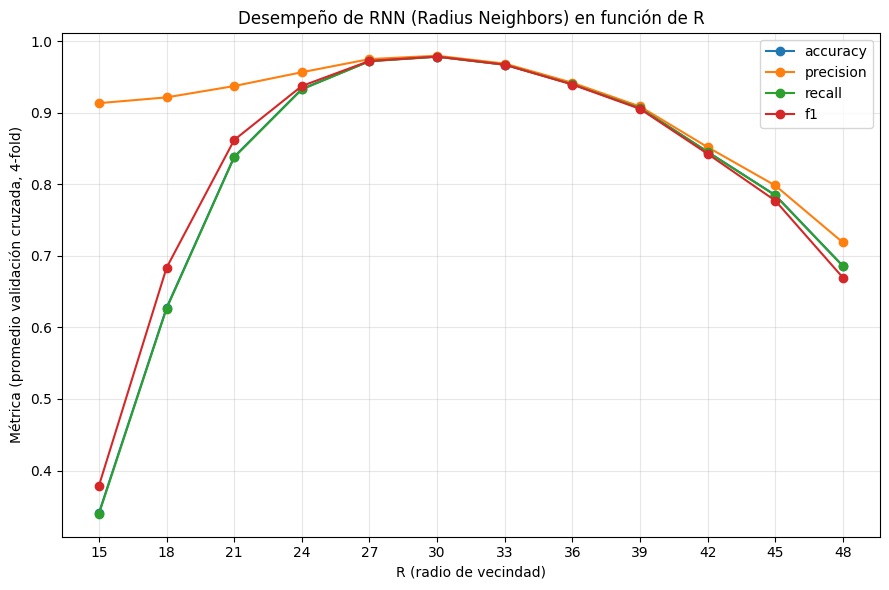

In [12]:
# Figura: métricas de desempeño vs R
plt.figure(figsize=(9, 6))
for m, valores in metricas_rnn.items():
    plt.plot(rango_R, valores, marker='o', label=m)
plt.xlabel('R (radio de vecindad)')
plt.ylabel('Métrica (promedio validación cruzada, 4-fold)')
plt.title('Desempeño de RNN (Radius Neighbors) en función de R')
plt.xticks(rango_R)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('rnn_metricas_vs_R.png', dpi=120)
plt.show()


### Selección del mejor valor de R

De la misma forma que con KNN, se selecciona el valor de R que maximiza el **F1-score macro** promedio en la validación cruzada.


In [13]:
mejor_idx_R = int(np.argmax(metricas_rnn['f1']))
mejor_R = rango_R[mejor_idx_R]

print(f"Mejor valor de R: {mejor_R}")
print(f"  Accuracy  (CV): {metricas_rnn['accuracy'][mejor_idx_R]:.4f}")
print(f"  Precision (CV): {metricas_rnn['precision'][mejor_idx_R]:.4f}")
print(f"  Recall    (CV): {metricas_rnn['recall'][mejor_idx_R]:.4f}")
print(f"  F1-score  (CV): {metricas_rnn['f1'][mejor_idx_R]:.4f}")


Mejor valor de R: 30
  Accuracy  (CV): 0.9784
  Precision (CV): 0.9796
  Recall    (CV): 0.9782
  F1-score  (CV): 0.9784


### Evaluación del modelo RNN final sobre el conjunto de prueba

In [14]:
modelo_rnn_final = RadiusNeighborsClassifier(radius=mejor_R, outlier_label='most_frequent')
modelo_rnn_final.fit(X_train, y_train)
y_pred_rnn = modelo_rnn_final.predict(X_test)

acc_rnn = accuracy_score(y_test, y_pred_rnn)
prec_rnn = precision_score(y_test, y_pred_rnn, average='macro')
rec_rnn = recall_score(y_test, y_pred_rnn, average='macro')
f1_rnn = f1_score(y_test, y_pred_rnn, average='macro')

print(f"Resultados RNN (R={mejor_R}) sobre el conjunto de PRUEBA:")
print(f"  Accuracy : {acc_rnn:.4f}")
print(f"  Precision: {prec_rnn:.4f}")
print(f"  Recall   : {rec_rnn:.4f}")
print(f"  F1-score : {f1_rnn:.4f}")
print()
print(classification_report(y_test, y_pred_rnn))


Resultados RNN (R=30) sobre el conjunto de PRUEBA:
  Accuracy : 0.9722
  Precision: 0.9734
  Recall   : 0.9717
  F1-score : 0.9716

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.88      1.00      0.94        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.95      1.00      0.97        36
           8       0.94      0.83      0.88        35
           9       1.00      0.94      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



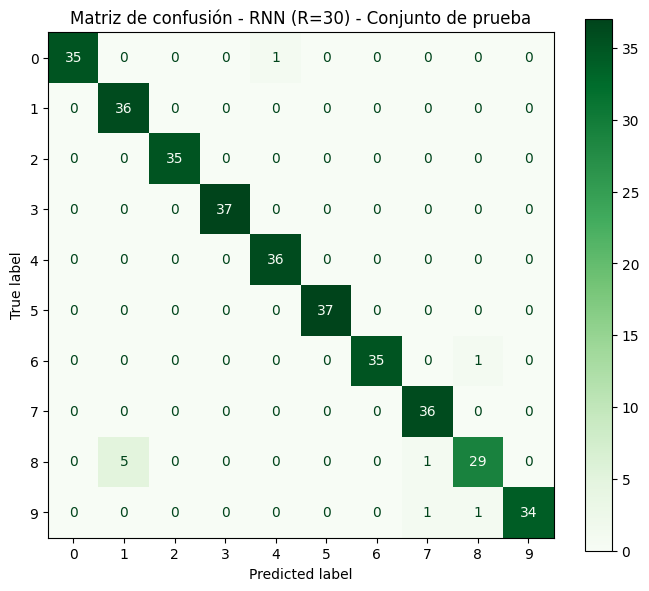

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rnn, ax=ax, cmap='Greens')
ax.set_title(f'Matriz de confusión - RNN (R={mejor_R}) - Conjunto de prueba')
plt.tight_layout()
plt.savefig('rnn_matriz_confusion.png', dpi=120)
plt.show()


## 7. Comparación de resultados y conclusiones

In [16]:
comparacion = {
    'Modelo': ['KNN', 'RNN'],
    'Hiperparámetro óptimo': [f'K = {mejor_K}', f'R = {mejor_R}'],
    'Accuracy (test)': [acc_knn, acc_rnn],
    'Precision (test)': [prec_knn, prec_rnn],
    'Recall (test)': [rec_knn, rec_rnn],
    'F1-score (test)': [f1_knn, f1_rnn]
}

import pandas as pd
df_comparacion = pd.DataFrame(comparacion)
df_comparacion


,Modelo,Hiperparámetro óptimo,Accuracy (test),Precision (test),Recall (test),F1-score (test)
0,KNN,K = 1,0.986111,0.986575,0.985873,0.985891
1,RNN,R = 30,0.972222,0.973387,0.971746,0.971639


### Conclusiones

- El clasificador **KNN** encuentra su mejor desempeño con un valor bajo de K, lo cual es consistente con el hecho de que el dataset `digits` tiene clases bien separadas en el espacio de características: los vecinos más cercanos casi siempre pertenecen a la misma clase.
- El clasificador **RNN (Radius Neighbors)** es más sensible a la elección del hiperparámetro R: valores muy pequeños de R dejan muchas muestras sin vecinos dentro del radio (bajo desempeño), mientras que valores muy grandes de R agrupan vecinos de clases distintas, degradando también el desempeño. Existe un rango intermedio de R donde el modelo alcanza su mejor desempeño.
- En general, ambos modelos logran un desempeño alto sobre este dataset, dado que las imágenes de dígitos (8x8 píxeles) generan una representación de baja dimensionalidad (64 características) donde las clases están razonablemente bien separadas.
- **Nota:** el desempeño de RNN es más sensible a la escala de las características que el de KNN, por lo que en problemas donde la escala de las variables no sea homogénea sería recomendable estandarizar los datos (`StandardScaler`) antes de aplicar RNN.
